**Import Labraries & Daaset**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
from google.colab import files

uploaded = files.upload()

Saving Sample - Superstore.csv to Sample - Superstore (1).csv


**Load the Dataset**

In [3]:
df = pd.read_csv("Sample - Superstore.csv", encoding="latin1")

df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


**Check Dataset Size**

In [4]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 9994
Number of columns: 21


**Check Customer Information**

In [5]:
print("Total unique customers:", df["Customer ID"].nunique())

df[["Customer ID", "Customer Name", "Sales", "Quantity", "Profit"]].head(10)

Total unique customers: 793


,Customer ID,Customer Name,Sales,Quantity,Profit
0,CG-12520,Claire Gute,261.9600,2,41.9136
1,CG-12520,Claire Gute,731.9400,3,219.5820
2,DV-13045,Darrin Van Huff,14.6200,2,6.8714
3,SO-20335,Sean O'Donnell,957.5775,5,-383.0310
4,SO-20335,Sean O'Donnell,22.3680,2,2.5164
5,BH-11710,Brosina Hoffman,48.8600,7,14.1694
6,BH-11710,Brosina Hoffman,7.2800,4,1.9656
7,BH-11710,Brosina Hoffman,907.1520,6,90.7152
8,BH-11710,Brosina Hoffman,18.5040,3,5.7825
9,BH-11710,Brosina Hoffman,114.9000,5,34.4700


**Create Customer-Level Data**

In [6]:
customer_data = df.groupby(['Customer ID', 'Customer Name']).agg({
    'Sales': 'sum',
    'Quantity': 'sum',
    'Profit': 'sum',
    'Order ID': 'nunique'
}).reset_index()

customer_data.rename(columns={
    'Sales': 'Total Sales',
    'Quantity': 'Total Quantity',
    'Profit': 'Total Profit',
    'Order ID': 'Order Frequency'
}, inplace=True)

customer_data.head()

,Customer ID,Customer Name,Total Sales,Total Quantity,Total Profit,Order Frequency
0,AA-10315,Alex Avila,5563.560,30,-362.8825,5
1,AA-10375,Allen Armold,1056.390,41,277.3824,9
2,AA-10480,Andrew Allen,1790.512,36,435.8274,4
3,AA-10645,Anna Andreadi,5086.935,64,857.8033,6
4,AB-10015,Aaron Bergman,886.156,13,129.3465,3


**Check Number of Customer**

In [7]:
print("Total Customers:", customer_data.shape[0])

Total Customers: 793


**View Customer Statistics.**

In [8]:
customer_data.describe()

,Total Sales,Total Quantity,Total Profit,Order Frequency
count,793.000000,793.000000,793.000000,793.000000
mean,2896.848500,47.759142,361.156396,6.316520
std,2628.670117,24.842915,894.261812,2.550885
min,4.833000,2.000000,-6626.389500,1.000000
25%,1146.050000,30.000000,36.613100,5.000000
50%,2256.394000,44.000000,227.833800,6.000000
75%,3785.276000,63.000000,560.007800,8.000000
max,25043.050000,150.000000,8981.323900,17.000000


**Check Missing Values**

In [9]:
customer_data.isnull().sum()

,0
Customer ID,0
Customer Name,0
Total Sales,0
Total Quantity,0
Total Profit,0
Order Frequency,0


**Find Top 10 Customers by Sales.**

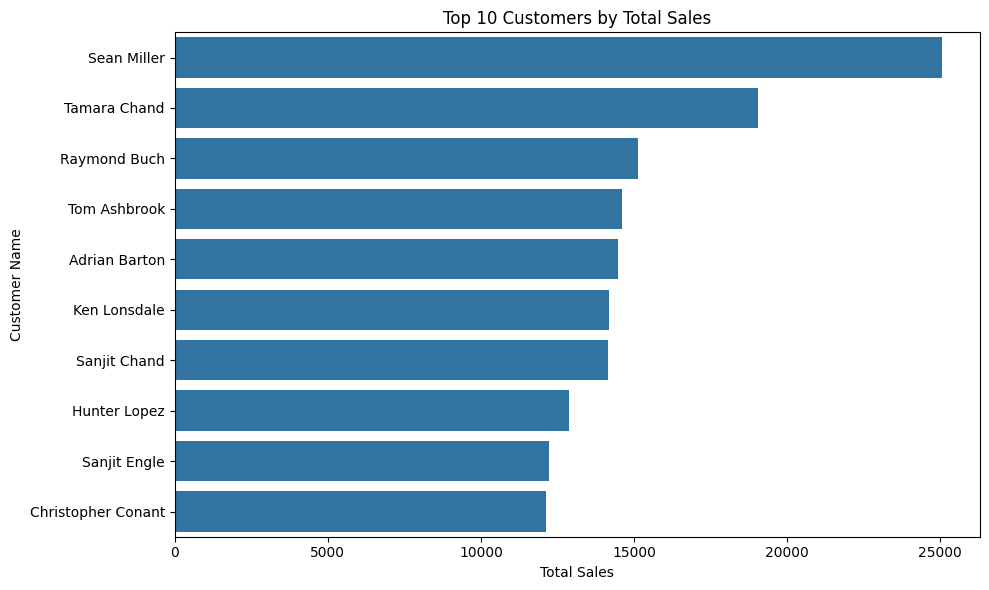

In [10]:
top_customers = customer_data.nlargest(10, 'Total Sales')

plt.figure(figsize=(10,6))

sns.barplot(
    data=top_customers,
    x='Total Sales',
    y='Customer Name'
)

plt.title('Top 10 Customers by Total Sales')
plt.xlabel('Total Sales')
plt.ylabel('Customer Name')
plt.tight_layout()
plt.show()

**Create Customer Segments**

In [11]:
customer_data['Customer Segment'] = pd.qcut(
    customer_data['Total Sales'],
    q=3,
    labels=['Low Value', 'Medium Value', 'High Value']
)

customer_data.head(10)

,Customer ID,Customer Name,Total Sales,Total Quantity,Total Profit,Order Frequency,Customer Segment
0,AA-10315,Alex Avila,5563.560,30,-362.8825,5,High Value
1,AA-10375,Allen Armold,1056.390,41,277.3824,9,Low Value
2,AA-10480,Andrew Allen,1790.512,36,435.8274,4,Medium Value
3,AA-10645,Anna Andreadi,5086.935,64,857.8033,6,High Value
4,AB-10015,Aaron Bergman,886.156,13,129.3465,3,Low Value
5,AB-10060,Adam Bellavance,7755.620,56,2054.5885,8,High Value
6,AB-10105,Adrian Barton,14473.571,73,5444.8055,10,High Value
7,AB-10150,Aimee Bixby,966.710,37,313.6597,5,Low Value
8,AB-10165,Alan Barnes,1113.838,48,220.8130,8,Low Value
9,AB-10255,Alejandro Ballentine,914.532,39,264.5675,9,Low Value


**Count Customers in Each Segment.**

In [12]:
segment_counts = customer_data['Customer Segment'].value_counts()

print(segment_counts)

Customer Segment
Low Value       265
High Value      265
Medium Value    263
Name: count, dtype: int64


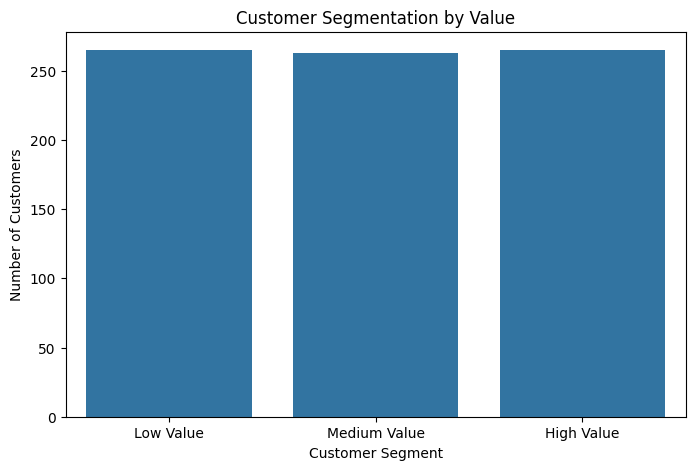

In [13]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=customer_data,
    x='Customer Segment',
    order=['Low Value', 'Medium Value', 'High Value']
)

plt.title('Customer Segmentation by Value')
plt.xlabel('Customer Segment')
plt.ylabel('Number of Customers')
plt.show()

**Compare Sales and Profit**

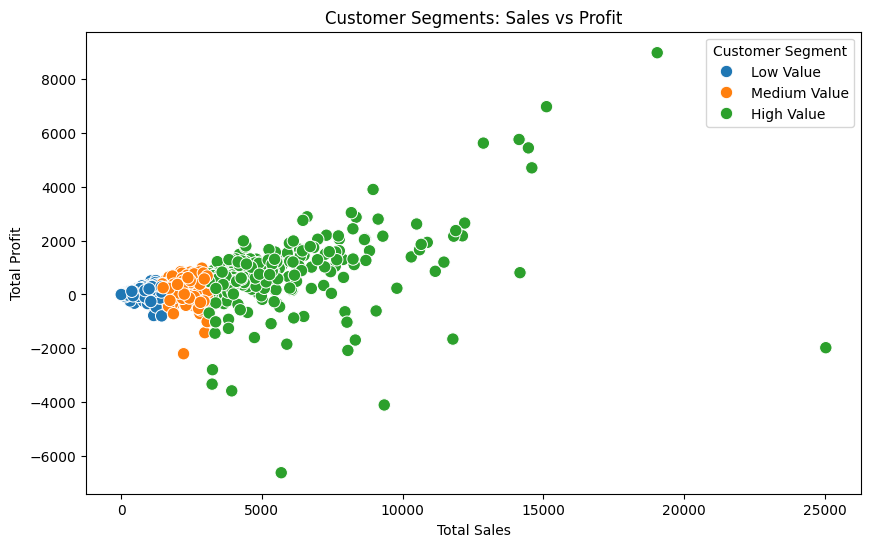

In [14]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=customer_data,
    x='Total Sales',
    y='Total Profit',
    hue='Customer Segment',
    s=80
)

plt.title('Customer Segments: Sales vs Profit')
plt.xlabel('Total Sales')
plt.ylabel('Total Profit')
plt.show()

**Segment Summary**

In [15]:
segment_summary = customer_data.groupby(
    'Customer Segment',
    observed=True
).agg({
    'Total Sales': 'mean',
    'Total Quantity': 'mean',
    'Total Profit': 'mean',
    'Order Frequency': 'mean'
}).round(2)

segment_summary

,Total Sales,Total Quantity,Total Profit,Order Frequency
Customer Segment,,,,
Low Value,802.68,28.06,71.66,4.54
Medium Value,2262.78,48.95,237.21,6.63
High Value,5620.30,66.28,773.66,7.77


**Sales Contribution by Segment**

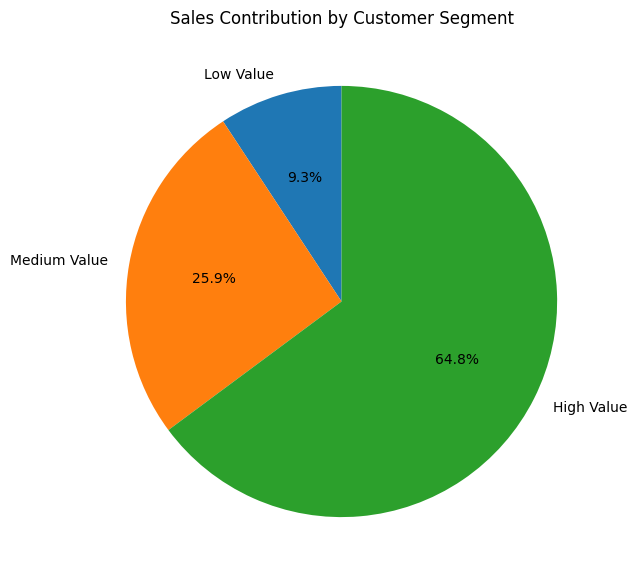

In [16]:
segment_sales = customer_data.groupby(
    'Customer Segment',
    observed=True
)['Total Sales'].sum()

plt.figure(figsize=(7,7))

plt.pie(
    segment_sales,
    labels=segment_sales.index,
    autopct='%1.1f%%',
    startangle=90
)

plt.title('Sales Contribution by Customer Segment')
plt.show()

**Find the Most Valuable Customers**

In [17]:
high_value_customers = customer_data[
    customer_data['Customer Segment'] == 'High Value'
].sort_values('Total Sales', ascending=False)

high_value_customers[
    ['Customer Name', 'Total Sales', 'Total Profit', 'Order Frequency']
].head(10)

,Customer Name,Total Sales,Total Profit,Order Frequency
700,Sean Miller,25043.050,-1980.7393,5
741,Tamara Chand,19052.218,8981.3239,5
621,Raymond Buch,15117.339,6976.0959,6
730,Tom Ashbrook,14595.620,4703.7883,4
6,Adrian Barton,14473.571,5444.8055,10
434,Ken Lonsdale,14175.229,806.8550,12
669,Sanjit Chand,14142.334,5757.4119,9
327,Hunter Lopez,12873.298,5622.4292,6
683,Sanjit Engle,12209.438,2650.6769,11
131,Christopher Conant,12129.072,2177.0493,5


**Profit Contribution by Segment**

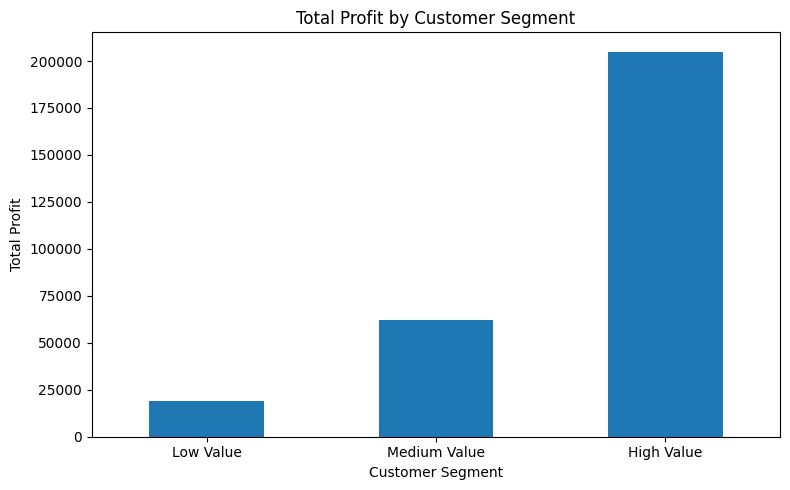

In [18]:
segment_profit = customer_data.groupby(
    'Customer Segment',
    observed=True
)['Total Profit'].sum()

plt.figure(figsize=(8,5))
segment_profit.plot(kind='bar')

plt.title('Total Profit by Customer Segment')
plt.xlabel('Customer Segment')
plt.ylabel('Total Profit')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

**Business Insights**



1. Customers were divided into Low Value, Medium Value, and High Value segments based on their total purchasing value.

2. High-value customers contribute a significant portion of overall sales and should be prioritized for customer retention strategies.

3. Medium-value customers represent an opportunity for growth through targeted promotions, personalized recommendations, and loyalty programs.

4. Low-value customers can be encouraged to purchase more frequently through appropriate offers and marketing campaigns.

5. Sales and profit do not always increase proportionally, indicating that factors such as discounts and product profitability can influence customer-level profitability.

6. Customer segmentation can help businesses allocate marketing resources more effectively and develop different strategies for different customer groups.

**Conclusion**



The customer segmentation analysis successfully divided customers into **Low Value, Medium Value, and High Value** groups based on their total sales. High-value customers contribute significantly to overall sales and are important for business growth and customer retention. Medium-value customers have the potential to become high-value customers through targeted offers and loyalty programs. Low-value customers can be encouraged to purchase more frequently through suitable promotions. Overall, customer segmentation helps businesses better understand customer behavior and develop more effective marketing and sales strategies.
